# Training with MJLab (MuJoCo Warp) and rl_games

[MJLab](https://github.com/mujocolab/mjlab) provides Isaac Lab's manager-based task API
on top of MuJoCo Warp — GPU-parallel robotics environments with no Isaac Sim dependency.
rl_games ships a native wrapper (`env_name: mjlab_*`), shipped configs under
`rl_games/configs/mjlab/`, and benchmark results in `docs/MJLAB.md`.

This notebook trains a **Unitree Go1 flat-terrain velocity policy** at small scale
(2048 envs, 1000 epochs, ~6-8 min on a modern NVIDIA GPU) to demonstrate the pipeline
end-to-end. Full-scale training (4096 envs, 10k epochs) uses the shipped config
unchanged except for `num_actors`/`minibatch_size`/`max_epochs` — see the last cell.

**Requirements:** Linux, NVIDIA GPU, recent driver. Everything stays on the GPU:
simulation (Warp), observations, actions, and the PPO update — no CPU round-trips.

In [1]:
# Install (uncomment on a fresh environment):
# %pip install rl-games mjlab warp-lang

import torch, mjlab, warp
from importlib.metadata import version
print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "| rl_games", version("rl-games"))

torch 2.12.0+cu130 | cuda True | rl_games 2.0.0


In [2]:
# Notebook-scale training config: the shipped Go1 recipe with smaller geometry.
# (Shipped full-scale config: rl_games/configs/mjlab/ppo_go1_velocity.yaml)
import yaml

with open('../rl_games/configs/mjlab/ppo_go1_velocity.yaml') as f:
    cfg = yaml.safe_load(f)

c = cfg['params']['config']
c['num_actors'] = 2048         # full scale: 4096; fewer envs risks a 'stander' policy (see viz notebook's probe)
c['minibatch_size'] = 8192     # keep 16k-32k at full scale; scale splits, not size
c['max_epochs'] = 1000         # full scale: 10000
cv = c.get('central_value_config')
if cv:
    cv['minibatch_size'] = 8192  # asymmetric critic dataset must divide the batch too
c['name'] = 'MJLab_Go1_notebook'
c['save_frequency'] = 100
c['device'] = 'cuda:0'
print(yaml.safe_dump({'num_actors': c['num_actors'], 'minibatch_size': c['minibatch_size'],
                      'max_epochs': c['max_epochs'], 'schedule_type': c.get('schedule_type'),
                      'learning_rate': c.get('learning_rate')}, sort_keys=False))

num_actors: 2048
minibatch_size: 8192
max_epochs: 1000
schedule_type: standard
learning_rate: 0.001



In [3]:
# Train. rl_games' Runner drives everything; MJLab envs are created by the
# registered 'mjlab_go1_velocity' vecenv type.
from rl_games.torch_runner import Runner

runner = Runner()
runner.load(cfg)
runner.run({'train': True})

self.seed = 42
Started to train
Adding Central Value Network
Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/viktor/.cache/warp/1.14.0
Setting seed: 42


Module mujoco_warp._src.smooth 6acfd0b load on device 'cuda:0' took 2.63 ms  (cached)
Module _nxn_broadphase__locals__kernel_df6640ed df6640e load on device 'cuda:0' took 0.52 ms  (cached)


Module _primitive_narrowphase__locals__primitive_narrowphase_ad5f51d1 ad5f51d load on device 'cuda:0' took 1.08 ms  (cached)
Module mujoco_warp._src.constraint 880bd7f load on device 'cuda:0' took 0.34 ms  (cached)
Module _friction_dof__locals__kernel_3c14efda 3c14efd load on device 'cuda:0' took 0.43 ms  (cached)
Module _limit_slide_hinge__locals__kernel_4d6c55ab 4d6c55a load on device 'cuda:0' took 0.42 ms  (cached)
Module _efc_contact_init__locals__kernel_744a1fda 744a1fd load on device 'cuda:0' took 0.37 ms  (cached)
Module _efc_contact_jac_dense__locals__kernel_800e572c c417494 load on device 'cuda:0' took 0.46 ms  (cached)
Module _efc_contact_update__locals__kernel_c40b0799 c40b079 load on device 'cuda:0' took 0.40 ms  (cached)
Module mujoco_warp._src.sensor 4bf7c4d load on device 'cuda:0' took 1.80 ms  (cached)
Module mujoco_warp._src.forward a27d81a load on device 'cuda:0' took 0.95 ms  (cached)
Module mujoco_warp._src.passive e551f58 load on device 'cuda:0' took 0.75 ms  (cach

Module _tile_cholesky_factorize_solve_block__locals__kernel_419fe7e0 4a5ffaf load on device 'cuda:0' took 34.25 ms  (cached)
Module mujoco_warp._src.solver ee39d44 load on device 'cuda:0' took 2.91 ms  (cached)
Module _solve_init_jaref_kernel__locals__kernel_5a4f7ef7 5a4f7ef load on device 'cuda:0' took 0.39 ms  (cached)
Module mul_m_kernel__locals___mul_m_fd2186c4 fd2186c load on device 'cuda:0' took 0.38 ms  (cached)
Module _update_constraint_efc__locals__kernel_d40ce3fb d40ce3f load on device 'cuda:0' took 0.37 ms  (cached)
Module _update_gradient_JTDAJ_dense_tiled__locals__kernel_d367b9e1 476814b load on device 'cuda:0' took 0.88 ms  (cached)
Module _update_gradient_cholesky__locals__kernel_5c291ae5 6445ad4 load on device 'cuda:0' took 39.32 ms  (cached)
Module _linesearch_iterative_kernel__locals__kernel_3723f0ce 1b62d77 load on device 'cuda:0' took 0.78 ms  (cached)
Module _contact_sort__locals__contact_sort_321f5f3e 33ea4e1 load on device 'cuda:0' took 0.47 ms  (cached)
Module m

Module mujoco_warp._src.render_util ff4fe80 load on device 'cuda:0' took 0.52 ms  (cached)
Module mujoco_warp._src.bvh d9cfd91 load on device 'cuda:0' took 0.81 ms  (cached)
Module mujoco_warp._src.ray d79c433 load on device 'cuda:0' took 1.17 ms  (cached)

+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 2048  |
| Environment device     | cuda  |
| Environment seed       | 42    |
| Physics step-size      | 0.005 |
| Environment step-size  | 0.02  |
+------------------------+-------+

[INFO] <EventManager> contains 3 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
+--------+-------------------

...

fps step: 79506 fps step and policy inference: 74499 fps total: 57457 epoch: 996/1000 frames: 48955392


fps step: 72354 fps step and policy inference: 68336 fps total: 53589 epoch: 997/1000 frames: 49004544


fps step: 73844 fps step and policy inference: 69603 fps total: 54770 epoch: 998/1000 frames: 49053696


fps step: 72286 fps step and policy inference: 68093 fps total: 53619 epoch: 999/1000 frames: 49102848


fps step: 71674 fps step and policy inference: 67709 fps total: 53531 epoch: 1000/1000 frames: 49152000
=> saving checkpoint 'runs/MJLab_Go1_notebook_17-22-17-29/nn/last_MJLab_Go1_notebook_ep_1000_rew_81.9577.pth'
=> saving checkpoint 'runs/MJLab_Go1_notebook_17-22-17-29/nn/last_MJLab_Go1_notebook_ep_1000_rew__81.9577_.pth'
MAX EPOCHS NUM!


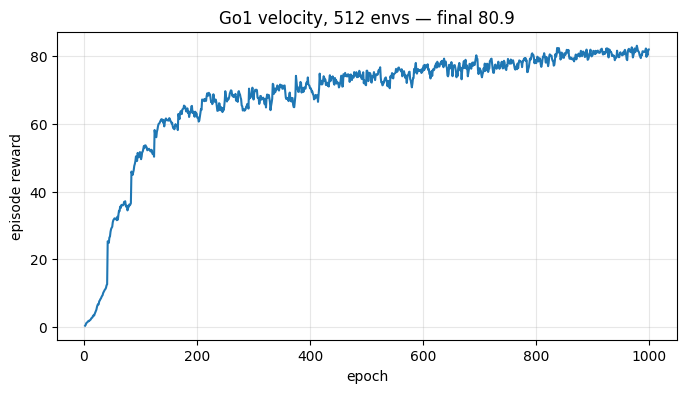

checkpoint: runs/MJLab_Go1_notebook_17-22-17-29/nn/MJLab_Go1_notebook.pth


In [4]:
# Plot the training curve from the run's TensorBoard events.
import glob, numpy as np, matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

run_dir = sorted(glob.glob('runs/MJLab_Go1_notebook*'))[-1]
ea = EventAccumulator(run_dir + '/summaries', size_guidance={'scalars': 0}); ea.Reload()
s = ea.Scalars('rewards/iter')
steps, vals = [x.step for x in s], [x.value for x in s]
plt.figure(figsize=(8, 4))
plt.plot(steps, vals)
plt.xlabel('epoch'); plt.ylabel('episode reward'); plt.grid(alpha=0.3)
plt.title(f'Go1 velocity, 512 envs — final {np.mean(vals[-20:]):.1f}')
plt.show()
print('checkpoint:', run_dir + '/nn/MJLab_Go1_notebook.pth')

## Full-scale training

```bash
python runner.py --train --file rl_games/configs/mjlab/ppo_go1_velocity.yaml
```

- 4096 envs, 10k epochs (~2-3 h on an RTX 4090); multi-GPU via
  `torchrun --standalone --nproc_per_node=N runner.py --train --file ...`
  with `multi_gpu: true` — keep **envs per GPU constant** (weak scaling).
- Benchmark results, G1/lift/dexterous-hand configs and tuning notes: `docs/MJLAB.md`.
- Visualize any checkpoint with the companion `mjlab_visualization.ipynb`.